In [120]:
#pip install scikit

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [121]:
np.random.seed(42)

length= np.random.normal(loc=75, scale=15, size=50).round(1)
weights = np.random.normal(loc=75, scale=15, size=50).round(1)
genders = np.random.choice([0, 1], size=50)

data = {
	'weight': weights,
	'length': length,
    'gender': genders
}
df = pd.DataFrame(data)

print(df)

    weight  length  gender
0     79.9    82.5       0
1     69.2    72.9       1
2     64.8    84.7       0
3     84.2    97.8       0
4     90.5    71.5       0
5     89.0    71.5       1
6     62.4    98.7       1
7     70.4    86.5       1
8     80.0    68.0       0
9     89.6    83.1       0
10    67.8    68.0       1
11    72.2    68.0       1
12    58.4    78.6       1
13    57.1    46.3       1
14    87.2    49.1       0
15    95.3    66.6       1
16    73.9    59.8       0
17    90.1    79.7       1
18    80.4    61.4       0
19    65.3    53.8       1
20    80.4    97.0       1
21    98.1    71.6       1
22    74.5    76.0       1
23    98.5    53.6       0
24    35.7    66.8       1
25    87.3    76.7       0
26    76.3    57.7       0
27    70.5    80.6       0
28    76.4    66.0       0
29    45.2    70.6       1
30    71.7    66.0       0
31    80.4   102.8       0
32    97.2    74.8       0
33    67.2    59.1       1
34    62.9    87.3       1
35    67.5    56.7       1
3

In [122]:
train_df, test_val_df = train_test_split(df, test_size=0.4, random_state=42)
print(train_df.shape)
print(test_val_df.shape)

(30, 3)
(20, 3)


In [123]:
test_df, val_df = train_test_split(test_val_df, test_size=0.5, random_state=42)
print(train_df.shape)
print(test_df.shape)
print(val_df.shape)

(30, 3)
(10, 3)
(10, 3)


In [124]:
model = DecisionTreeClassifier(random_state=42)
model.fit(
	X=train_df[["weight", "length"]], 
	y=train_df["gender"]
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [125]:
test_prediction_y = model.predict(
	X=test_df[["weight", "length"]]
)
print(test_prediction_y)
print(np.array(test_df["gender"]))


[0 1 0 0 1 0 1 0 1 0]
[0 0 1 1 1 0 0 1 0 0]


In [126]:
score = accuracy_score(
	y_true=test_df["gender"],
	y_pred=test_prediction_y
)

print(score)

0.4


In [127]:
print(model.get_depth())

5


In [128]:
bestDepth = -1
bestScore = -1

for max_depth in range(1, model.get_depth()):
	model_tune = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
	model_tune.fit(
		X=train_df[["weight", "length"]], 
		y=train_df["gender"]
	)

	test_prediction_y = model_tune.predict(
		X=test_df[["weight", "length"]]
	)
	# print(test_prediction_y)
	# print(np.array(test_df["gender"]))

	score = accuracy_score(
		y_true=test_df["gender"],
		y_pred=test_prediction_y
	)
	if bestScore < score:
		bestScore = score
		bestDepth = max_depth
		

print(bestScore)
print(bestDepth)

0.7
1


In [ ]:
model_test = DecisionTreeClassifier(max_depth=bestDepth, random_state=42)
model_test.fit(
	X=train_df[["weight", "length"]], 
	y=train_df["gender"]
)

test_prediction_y_test = model_tune.predict(
	X=test_df[["weight", "length"]]
)

score = accuracy_score(
	y_true=test_df["gender"],
	y_pred=test_prediction_y
)

print(score)

0.5


[Text(0.5357142857142857, 0.9, 'x[0] <= 73.05\ngini = 0.491\nsamples = 30\nvalue = [13, 17]\nclass = girl'),
 Text(0.35714285714285715, 0.7, 'x[1] <= 73.1\ngini = 0.375\nsamples = 16\nvalue = [4, 12]\nclass = girl'),
 Text(0.4464285714285714, 0.8, 'True  '),
 Text(0.21428571428571427, 0.5, 'x[1] <= 55.9\ngini = 0.165\nsamples = 11\nvalue = [1, 10]\nclass = girl'),
 Text(0.14285714285714285, 0.3, 'x[0] <= 68.1\ngini = 0.444\nsamples = 3\nvalue = [1, 2]\nclass = girl'),
 Text(0.07142857142857142, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = boy'),
 Text(0.21428571428571427, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = girl'),
 Text(0.2857142857142857, 0.3, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]\nclass = girl'),
 Text(0.5, 0.5, 'x[1] <= 85.6\ngini = 0.48\nsamples = 5\nvalue = [3, 2]\nclass = boy'),
 Text(0.42857142857142855, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]\nclass = boy'),
 Text(0.5714285714285714, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = g

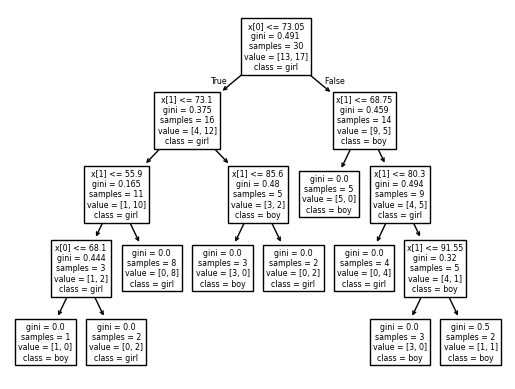

In [133]:
plot_tree(model_tune, class_names=["boy", "girl"])


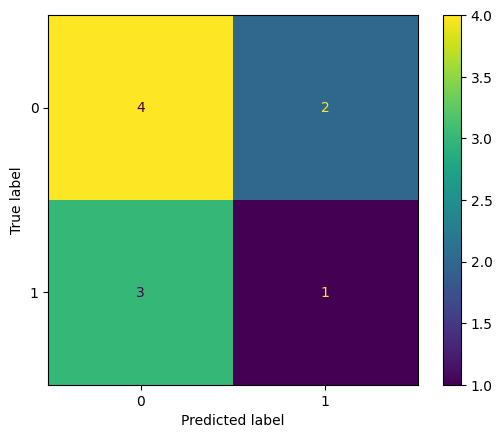

In [ ]:
cm = confusion_matrix(y_true=test_df["gender"], y_pred=test_prediction_y)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()